# EXERCISE 2 - SENTIMENT ANALYSIS CLASSIFICATION TASK WITH CNNs

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import tarfile
from sklearn.datasets import load_files

In [2]:
from sklearn.datasets import load_files

movies_train = load_files(container_path="aclImdb_v1/aclImdb/train", encoding="utf-8")
movies_test = load_files(container_path="aclImdb_v1/aclImdb/test", encoding="utf-8")

In [3]:
# Transform train dataset into a dataframe
data_train = {'reviews': movies_train.data, 'sentiment': movies_train.target}
df_train = pd.DataFrame(data_train)

# Transform test dataset into a dataframe
data_test = {'reviews': movies_test.data, 'sentiment': movies_test.target}
df_test = pd.DataFrame(data_test)

del movies_train, movies_test # free memory

print(df_train.iloc[:10])
print('----------------------------------------------------------------------------------------')
print(df_test.iloc[:10])

                                             reviews  sentiment
0  Full of (then) unknown actors TSF is a great b...          2
1  Amount of disappointment I am getting these da...          2
2  The future, we are told, are what we make of i...          2
3  Dan Katzir has produced a wonderful film that ...          1
4  If you want Scream or anything like the big-st...          1
5  Although its mold of 1949 appears somewhat mel...          2
6  Gloomy Sunday - Ein Lied von Liebe und Tod dir...          2
7  This movie was ridiculous. The plot is complet...          2
8  Why was this movie made? No doubt to sucker in...          2
9  Outlandish premise that rates low on plausibil...          0
----------------------------------------------------------------------------------------
                                             reviews  sentiment
0  Don't hate Heather Graham because she's beauti...          1
1  I don't know how this movie has received so ma...          0
2  I caught thi

Remove label 2

In [4]:
# Drop rows where 'sentiment' is 2 from train & test sets
df_train = df_train[df_train['sentiment'] != 2]
df_test = df_test[df_test['sentiment'] != 2]


df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

# Define the train dataset with 5000 rows by test set
df_train = pd.concat([df_train, df_test[:5000]])

print(f'The size of training set is: {len(df_train)}')
print(f'The size of test set is: {len(df_test[5000:])}')

The size of training set is: 30000
The size of test set is: 20000


In [5]:
from sklearn.utils import shuffle

# Shuffle dataframes because they are sorted.
df_train = shuffle(df_train)
df_train.reset_index(inplace=True, drop=True)
df_test = shuffle(df_test)
df_test.reset_index(inplace=True, drop=True)

df_train.head()

,reviews,sentiment
0,"I personally liked ""The Prophecy"" of 1995 a lo...",0
1,I managed to see this at the New York Internat...,1
2,Kubrick meets King. It sounded so promising ba...,0
3,I wish I'd known more about this movie when I ...,0
4,Somehow a woman working with a scientist puts ...,0


In [6]:
X_train = df_train.reviews
y_train = df_train.sentiment

In [7]:
# Split dev and test data
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(df_test.reviews[5000:], df_test.sentiment[5000:], test_size=0.5, random_state=42)
print(f"Number of observations in dev set: {X_dev.shape[0]}")
print(f"Number of observations in test set: {X_test.shape[0]}")

Number of observations in dev set: 10000
Number of observations in test set: 10000


# Preprocessing

* Replace non-word characters and numbers with empty string.
* Substitute multiple spaces with single space.
* Convert to lowercase.
* Remove stop words.
* Stemming with WordNetLemmatizer.

In [8]:
# Imports we need for preprocessing
import re
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

stemmer = WordNetLemmatizer()

# Import stop words for preprocessing
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dionysis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dionysis\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dionysis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
def preprocess(contents):
  """
    Preprocesses a list of texts by removing non-word characters, single characters, extra spaces,
    converting to lowercase, splitting into words, lemmatizing, and reconstructing the documents.

    Parameters:
    - contents (list): A list of texts to be preprocessed.

    Returns:
    - pd.Series: A Pandas Series containing preprocessed documents.
    """

  docs = []

  for doc in contents:

      # Remove non-word (special) characters such as punctuation, numbers etc
      document = re.sub(r'\W', ' ', str(doc))

      # Remove HTML <BR>
      document = re.sub(r'\s+br\s+',' ', str(document))

      # Remove all single characters
      document = re.sub(r'\s+[a-zA-Z]\s+', ' ', document)

      # Remove numbers
      document = re.sub(r'\b\d+\b', ' ', document)

      # Substitute multiple spaces with single space
      document = re.sub(r'\s+', ' ', document, flags=re.I) #re.I -> ignore case

      # Convert to Lowercase
      document = document.lower()

      # Split the document based on whitespaces (--> List of words)
      word_list = word_tokenize(document)

      # word_list = document.split()

      word_list = [word for word in word_list if word not in (stop_words)]

      # Lemmatization
      # word_list = [stemmer.lemmatize(word) for word in word_list]

      # # Reconstruct the document by joining the words on each whitespace
      document = ' '.join(word_list)

      # Append all documents into a list 'docs'
      docs.append(document)
  return pd.Series(docs)

In [10]:
# Preprocess texts
X_train = preprocess(X_train)
X_dev = preprocess(X_dev)
X_test = preprocess(X_test)

In [11]:
# Example of a preprocessed text
print(f'The non processed text:\n {df_train.reviews.iloc[10]}')
print('------------------------------------------------------------------------------------')
print('VS')
print('------------------------------------------------------------------------------------')
print(f'The processed text:\n {X_train[10]}')

The non processed text:
 I liked this show! I think it was nothing with wrong with it! Only that Spidey don't punch anyone but only for that the show doesn't suck! Some people only think this show is bad because of that. The story was great and it was fun when other heroes appeared like X-men, The Punisher, Daredevil and Iron Man! To bad Sandman never appear but i kinda like it! Best Spidey show ever!! My favorite episodes are: 1. Turning Point 2. Spider Wars 3. The Hobgoblin 4. The Alien Costume 5. Mutant Agenda<br /><br />But there are some episodes that was really really bad like: Rocket Racer and The Spot which was embarrassing to watch. And i don't like Morbius and Hydro Man. First of Morbius suck plasma instead of blood and i don't like vampires. And it irritates me that he was almost the main villain in Season 2. Of course i have to mentioned Hydro Man! He was terrible! I rather see Sandman! His last appearance was so terrible. And i don't like Spidey as the Man-spider!<br /><br

## Baseline Model (Logistic Regression with  TF-IDF and SVD)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use unigram & bi-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range=(1, 3),
                             max_features = 5000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf = vectorizer.transform(X_dev)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, type(X_train_tfidf))

(30000, 5000) <class 'scipy.sparse._csr.csr_matrix'>


In [13]:
# Reduce dimensionality using SVD 5000 --> 1000
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=1000, random_state=4321)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_dev_svd = svd.transform(X_dev_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print(X_train_svd.shape, type(X_train_svd))

(30000, 1000) <class 'numpy.ndarray'>


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve, auc
clf = LogisticRegression()
clf.fit(X_train_svd.tolist(), y_train)

# Validation set prediction
predictions = clf.predict(X_dev_svd.tolist())
print(f"\t\tClassification Report for developement set:\n\n {classification_report(y_dev, predictions)}")

# Test set prediction
predictions2 = clf.predict(X_test_svd.tolist())
print(f"\n\n\t\tClassification Report for testing set:\n\n {classification_report(y_test, predictions2)}")

		Classification Report for developement set:

               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4955
           1       0.88      0.90      0.89      5045

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



		Classification Report for testing set:

               precision    recall  f1-score   support

           0       0.90      0.89      0.89      5008
           1       0.89      0.90      0.90      4992

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# Building our model

Convert to one hot

In [15]:
import tensorflow as tf

y_train_1_hot = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_dev_1_hot = tf.keras.utils.to_categorical(y_dev, num_classes=2)


print(f"Y_train 1 hot: {y_train_1_hot}", "\n\n",f"Y_dev 1 hot:{y_dev_1_hot}")


Y_train 1 hot: [[1. 0.]
 [0. 1.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [0. 1.]] 

 Y_dev 1 hot:[[0. 1.]
 [1. 0.]
 [0. 1.]
 ...
 [0. 1.]
 [1. 0.]
 [0. 1.]]


In [16]:
from keras import backend as K
K.clear_session()

### TOKENIZATION

In [17]:
def is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

In [18]:
# !pip install spacy
# !python -m spacy download en_core_web_lg 

import spacy
import string
import numpy as np
from tqdm import tqdm

nlp = spacy.load('en_core_web_lg', disable=["tagger", "parser", "ner", "lemmatizer"])
from spacy.lang.en.stop_words import STOP_WORDS
nlp.add_pipe('sentencizer')


# Create a function that uses spacy to tokenize sentences and returns a nested list of tokenized sentences
def tokenize_data (data):
  """
    Tokenize our data
    :param data: list of documents
    :return: nested list of the tokenized documents
    """
  data_tokenized = []
  for idx in tqdm(range(len(data))):
    doc = nlp(data[idx])
    tokens = []
    for sent in doc.sents:
      for tok in sent:
        if '\n' in tok.text or "\t" in tok.text or "--" in tok.text or "*" in tok.text or\
        tok.text.lower() in STOP_WORDS or tok.text in string.punctuation or\
          all(x in string.punctuation for x in tok.text) or is_number(tok.text):
          continue
        if tok.text.strip():
          tokens.append(tok.text.replace('"',"'").strip().lower())
    data_tokenized.append(tokens)
  return data_tokenized

X_train_tokenized = tokenize_data(X_train) 
X_dev_tokenized = tokenize_data(X_dev)
X_test_tokenized = tokenize_data(X_test)



100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [01:23<00:00, 119.89it/s]


GET MAX SEQUENCE

In [19]:
mean_words = np.mean([len(x) for x in X_train_tokenized])
std_of_words = np.std([len(x) for x in X_train_tokenized])
               
# Get mean and std of sequence length on trainning set
print(f"Mean: {np.mean([len(x) for x in X_train_tokenized]): .2f}")
print(f"Std: {np.std([len(x) for x in X_train_tokenized]): .2f}")

In [22]:
X_test

0       reviewer toronto told need know film except no...
1       totally agree pitch black underground well wor...
2       true yawner bad film even chan series like goo...
3       film one fondest childhood memories seeing mup...
4       although rarely agree filmkrönikan say film aw...
                              ...                        
9995    brain screaming keep watching turn go bed couc...
9996    one pathetic predictable badly acted films eve...
9997    comes time every big name actor career get slo...
9998    surface day teaser first showed summer tossup ...
9999    action packed film makes feel peaceful relaxed...
Length: 10000, dtype: object

### VECTORIZATION

In [23]:
import tensorflow as tf
MAX_WORDS = 100000
MAX_SEQUENCE_LENGTH = 266 # mean + (2 * std)
EMBEDDING_DIM = 300

vectorizer = tf.keras.layers.TextVectorization(max_tokens=MAX_WORDS, output_mode='int',
                                               ngrams=1, output_sequence_length=MAX_SEQUENCE_LENGTH)

vectorizer.adapt(X_train)

In [24]:
# !pip install fasttext-wheel

import fasttext
import numpy as np
import fasttext.util


path = "C:\\Users\\dionysis\\Downloads\\cc.en.300.bin~\\cc.en.300.bin"
fasttext_model = fasttext.load_model(path)

embedding_matrix = np.zeros(shape=(MAX_WORDS, 300))

for w2idx, _word in enumerate(vectorizer.get_vocabulary()):
    # Skip PAD and UNK tokens
    if w2idx >= 2:
      embedding_matrix[w2idx] = fasttext_model.get_word_vector(_word)


In [25]:
# Example of the embeddings matrix
print(embedding_matrix[0,:])

del fasttext_model # save memory

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [28]:
import tensorflow.keras.backend as K

def recall(y_true, y_pred):

    """
    Recall metric.
    Only computes a batch-wise average of recall.
    Computes the recall, a metric for multi-label classification of
    how many relevant items are selected.
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall


def precision(y_true, y_pred):

    """
    Precision metric.
    Only computes a batch-wise average of precision.
    Computes the precision, a metric for multi-label classification of
    how many selected items are relevant.
    Source
    ------
    https://github.com/fchollet/keras/issues/5400#issuecomment-314747992
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


def f1(y_true, y_pred):

    """Calculate the F1 score."""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * ((p * r) / (p + r))


def accuracy(y_true, y_pred):
    return K.mean(K.equal(y_true, K.round(y_pred)), axis=1)

In [29]:
import os
from keras.callbacks import EarlyStopping
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [31]:
#Create and train a CNN model with (2,3,4)-gram filters using Keras functional API

FILTERS = 128  # the dimensionality of the output space (i.e. the number of output filters in the convolution)
DENSE = 512
N_CLASSES = 1


inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)
# Embeddings
embeddings = tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM,
                                       weights=[embedding_matrix],
                                       input_length=MAX_SEQUENCE_LENGTH,
                                       trainable=False)(x)
# Dropout over Embeddings
dropped_embeddings = tf.keras.layers.Dropout(rate=0.2)(embeddings)
# Multi-filter CNNs
pooled_convs,conv_layers = [],[]
filter_sizes = [2, 3, 4]

for n_gram in filter_sizes:
    for i in range(3):
        # n-gram convolutions with padding
        convs = tf.keras.layers.Conv1D(
            filters=FILTERS, kernel_size=n_gram,
            strides=1, padding="same", activation='relu',
            name='{}.{}-gram_Convolutions'.format(n_gram,i))(dropped_embeddings)
        conv_layers.append(convs) # store the convolution layers

            
    if len(conv_layers) > 1:
        concatenated_conv = tf.keras.layers.concatenate(conv_layers) # concatenate all the layers
    else:
        concatenated_conv = conv_layers[0]
    # Max-Pooling over time 
    pooled_convs.append(
        tf.keras.layers.GlobalMaxPooling1D(
            name='{}-gram_MaxPool'.format(n_gram))(concatenated_conv) # Max pool each stack of Conv layers
        )
# Concatenation of filters form all window sizes
concat =  tf.keras.layers.concatenate(pooled_convs)
concat = tf.keras.layers.Dropout(rate=0.5)(concat)
outputs = tf.keras.layers.Dense(N_CLASSES, activation='sigmoid')(concat)
model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[precision, recall, f1, accuracy])

print(model.summary())

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)          

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'checkpoints/keras_Deep_CNN_model',
    monitor='val_f1', verbose=1, save_best_only=True, mode='max')
history2 = model.fit(np.array(X_train),
                     y_train,
                     batch_size=32,
                     epochs=100,
                     verbose = 1,
                     callbacks=[checkpoint, early_stopping_callback ],
                     validation_data=(np.array(X_dev), y_dev),
                     shuffle=True)

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 text_vectorization (TextVe  (None, 266)                  0         ['input_2[0][0]']             
 ctorization)                                                                                     
                                                                                                  
 embedding_1 (Embedding)     (None, 266, 300)             3000000   ['text_vectorization[1][0]']  
                                                          0                                       
                                                                                            

                                                                                                  
 dropout_3 (Dropout)         (None, 2304)                 0         ['concatenate_7[0][0]']       
                                                                                                  
 dense_1 (Dense)             (None, 1)                    2305      ['dropout_3[0][0]']           
                                                                                                  
Total params: 31040257 (118.41 MB)
Trainable params: 1040257 (3.97 MB)
Non-trainable params: 30000000 (114.44 MB)
__________________________________________________________________________________________________
None
Epoch 1/100
938/938 [==============================] - ETA: 0s - loss: 0.4838 - precision: 0.7545 - recall: 0.7762 - f1: nan - accuracy: 0.7596
Epoch 1: val_f1 improved from -inf to 0.84694, saving model to checkpoints\keras_Deep_CNN_model
INFO:tensorflow:Assets written to: checkpoints\

INFO:tensorflow:Assets written to: checkpoints\keras_Deep_CNN_model\assets


938/938 [==============================] - 341s 361ms/step - loss: 0.4838 - precision: 0.7545 - recall: 0.7762 - f1: nan - accuracy: 0.7596 - val_loss: 0.3454 - val_precision: 0.8310 - val_recall: 0.8726 - val_f1: 0.8469 - val_accuracy: 0.8460
Epoch 2/100
938/938 [==============================] - ETA: 0s - loss: 0.3415 - precision: 0.8473 - recall: 0.8641 - f1: 0.8498 - accuracy: 0.8524
Epoch 2: val_f1 improved from 0.84694 to 0.86918, saving model to checkpoints\keras_Deep_CNN_model
INFO:tensorflow:Assets written to: checkpoints\keras_Deep_CNN_model\assets


INFO:tensorflow:Assets written to: checkpoints\keras_Deep_CNN_model\assets


...

938/938 [==============================] - 342s 365ms/step - loss: 0.0488 - precision: 0.9827 - recall: 0.9832 - f1: 0.9823 - accuracy: 0.9830 - val_loss: 0.3774 - val_precision: 0.8976 - val_recall: 0.9189 - val_f1: 0.9057 - val_accuracy: 0.9063
Epoch 42/100
938/938 [==============================] - ETA: 0s - loss: 0.0473 - precision: 0.9839 - recall: 0.9825 - f1: 0.9826 - accuracy: 0.9830
Epoch 42: val_f1 did not improve from 0.90572
938/938 [==============================] - 339s 362ms/step - loss: 0.0473 - precision: 0.9839 - recall: 0.9825 - f1: 0.9826 - accuracy: 0.9830 - val_loss: 0.3871 - val_precision: 0.8939 - val_recall: 0.9186 - val_f1: 0.9036 - val_accuracy: 0.9042
Epoch 43/100
938/938 [==============================] - ETA: 0s - loss: 0.0471 - precision: 0.9836 - recall: 0.9844 - f1: 0.9834 - accuracy: 0.9838
Epoch 43: val_f1 did not improve from 0.90572
938/938 [==============================] - 337s 360ms/step - loss: 0.0471 - precision: 0.9836 - recall: 0.9844 - f1: 0

INFO:tensorflow:Assets written to: checkpoints\keras_Deep_CNN_model\assets


938/938 [==============================] - 339s 361ms/step - loss: 0.0410 - precision: 0.9863 - recall: 0.9860 - f1: 0.9856 - accuracy: 0.9860 - val_loss: 0.4087 - val_precision: 0.8924 - val_recall: 0.9253 - val_f1: 0.9059 - val_accuracy: 0.9065
Epoch 52/100
938/938 [==============================] - ETA: 0s - loss: 0.0422 - precision: 0.9856 - recall: 0.9855 - f1: 0.9850 - accuracy: 0.9855
Epoch 52: val_f1 did not improve from 0.90594
938/938 [==============================] - 338s 360ms/step - loss: 0.0422 - precision: 0.9856 - recall: 0.9855 - f1: 0.9850 - accuracy: 0.9855 - val_loss: 0.4653 - val_precision: 0.9343 - val_recall: 0.8487 - val_f1: 0.8863 - val_accuracy: 0.8937
Epoch 53/100
938/938 [==============================] - ETA: 0s - loss: 0.0358 - precision: 0.9879 - recall: 0.9880 - f1: 0.9875 - accuracy: 0.9879
Epoch 53: val_f1 did not improve from 0.90594
938/938 [==============================] - 335s 357ms/step - loss: 0.0358 - precision: 0.9879 - recall: 0.9880 - f1: 0

938/938 [==============================] - ETA: 0s - loss: 0.0385 - precision: 0.9869 - recall: 0.9875 - f1: 0.9867 - accuracy: 0.9872
Epoch 70: val_f1 did not improve from 0.90594
938/938 [==============================] - 405s 432ms/step - loss: 0.0385 - precision: 0.9869 - recall: 0.9875 - f1: 0.9867 - accuracy: 0.9872 - val_loss: 0.4737 - val_precision: 0.8913 - val_recall: 0.9218 - val_f1: 0.9035 - val_accuracy: 0.9038
Epoch 71/100
938/938 [==============================] - ETA: 0s - loss: 0.0323 - precision: 0.9892 - recall: 0.9895 - f1: 0.9890 - accuracy: 0.9892
Epoch 71: val_f1 did not improve from 0.90594
938/938 [==============================] - 391s 416ms/step - loss: 0.0323 - precision: 0.9892 - recall: 0.9895 - f1: 0.9890 - accuracy: 0.9892 - val_loss: 0.5180 - val_precision: 0.9363 - val_recall: 0.8510 - val_f1: 0.8887 - val_accuracy: 0.8956
Epoch 72/100
938/938 [==============================] - ETA: 0s - loss: 0.0312 - precision: 0.9895 - recall: 0.9896 - f1: 0.9892 - 

Epoch 89/100
938/938 [==============================] - ETA: 0s - loss: 0.0331 - precision: 0.9893 - recall: 0.9892 - f1: 0.9889 - accuracy: 0.9892
Epoch 89: val_f1 did not improve from 0.90594
938/938 [==============================] - 372s 397ms/step - loss: 0.0331 - precision: 0.9893 - recall: 0.9892 - f1: 0.9889 - accuracy: 0.9892 - val_loss: 0.5442 - val_precision: 0.8785 - val_recall: 0.9373 - val_f1: 0.9039 - val_accuracy: 0.9027
Epoch 90/100
938/938 [==============================] - ETA: 0s - loss: 0.0307 - precision: 0.9905 - recall: 0.9900 - f1: 0.9899 - accuracy: 0.9903
Epoch 90: val_f1 did not improve from 0.90594
938/938 [==============================] - 373s 397ms/step - loss: 0.0307 - precision: 0.9905 - recall: 0.9900 - f1: 0.9899 - accuracy: 0.9903 - val_loss: 0.5000 - val_precision: 0.9065 - val_recall: 0.9094 - val_f1: 0.9051 - val_accuracy: 0.9068
Epoch 91/100
938/938 [==============================] - ETA: 0s - loss: 0.0321 - precision: 0.9900 - recall: 0.9906 - 

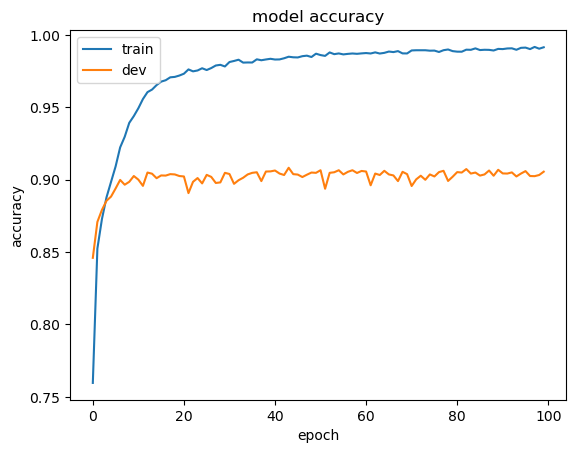

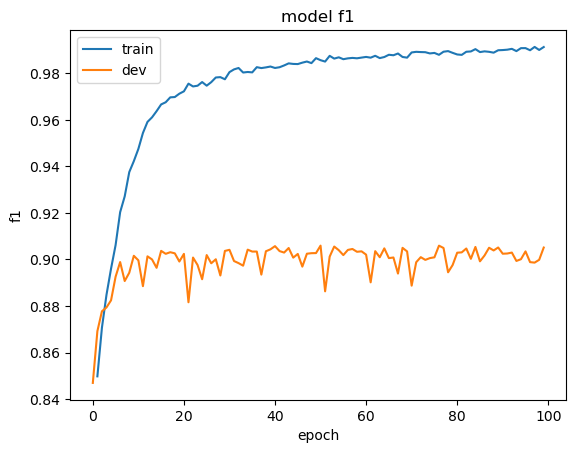

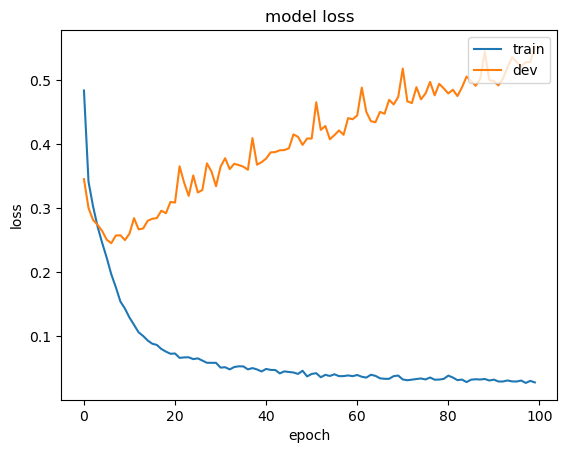

In [32]:
def training_history(history):
    %matplotlib inline
    import matplotlib.pyplot as plt

    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper left')
    plt.show()

    # summarize history for f1
    plt.plot(history.history['f1'])
    plt.plot(history.history['val_f1'])
    plt.title('model f1')
    plt.ylabel('f1')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper left')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper right')
    plt.show()

training_history(history2)

In [33]:
from sklearn.metrics import accuracy_score, f1_score

def predict_data(data):
    T = model.predict(data)
    # T2 = np.zeros_like(T)
    # for i in range(T.shape[0]):
    #   T2[i] = T[i]/np.max(T[i])
    C = np.ones((T.shape[1],)) / 2
    T = (C<=T)
    return T*1


print(f'Dev accuracy: {accuracy_score(y_dev, predict_data(X_dev))*100:.2f}%')
print(f'Dev micro-f1: {f1_score(y_dev, predict_data(X_dev), average="micro")*100:.2f}%')
print(f'Test accuracy: {accuracy_score(y_test, predict_data(X_test))*100:.2f}%')
print(f'Test micro-f1: {f1_score(y_test, predict_data(X_test), average="micro")*100:.2f}%')

313/313 [==============================] - 32s 100ms/step
Dev accuracy: 90.55%
313/313 [==============================] - 31s 98ms/step
Dev micro-f1: 90.55%
313/313 [==============================] - 31s 98ms/step
Test accuracy: 90.74%
313/313 [==============================] - 30s 97ms/step
Test micro-f1: 90.74%


313/313 [==============================] - 29s 93ms/step


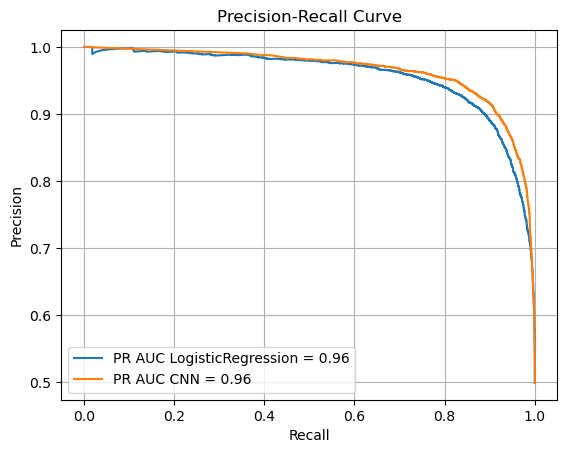

In [34]:
# Predict probabilities (Logistic Regression Baseline-1)
probs = clf.predict_proba(X_test_svd)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Calculate area under the curve (AUC) for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve for baseline model
plt.plot(recall, precision, label=f'PR AUC LogisticRegression = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)



# Predict probabilities of X_test using BiDirectional GRU + deep Self attention
y_pred = model.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Compute PR AUC
pr_auc = auc(recall, precision)

# Plot the PR curve for our model
plt.plot(recall, precision, label='PR AUC CNN = %0.2f' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')




In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, auc, precision_recall_curve, roc_auc_score

# Calculate predictions for clf
train_preds_clf = clf.predict_proba(X_train_svd)
train_preds_bin_clf = clf.predict(X_train_svd)

dev_preds_clf = clf.predict_proba(X_dev_svd)
dev_preds_bin_clf = clf.predict(X_dev_svd)

test_preds_clf = clf.predict_proba(X_test_svd)
test_preds_bin_clf = clf.predict(X_test_svd)




# Calculate predictions for CNN with deep self attention 
# predict train data
train_preds_CNN = model.predict(pd.Series(X_train))
train_preds_bin_CNN = np.array([[1] if pred >= 0.5 else [0] for pred in train_preds_CNN])

# predict dev data
dev_preds_CNN = model.predict(X_dev)
dev_preds_bin_CNN = np.array([[1] if pred >= 0.5 else [0] for pred in dev_preds_CNN])

# predict test data
test_preds_CNN = model.predict(X_test)
test_preds_bin_CNN = np.array([[1] if pred >= 0.5 else [0] for pred in test_preds_CNN])



313/313 [==============================] - 30s 96ms/step


In [36]:
train_preds_clf.shape

(30000, 2)

In [41]:
from operator import pos
from sklearn.metrics import precision_recall_curve, average_precision_score

# Define a function to calculate metrics for each class including PR-AUC for MLP
def calculate_class_metrics_model(y_true, y_pred, y_probs):
    report = classification_report(y_true, y_pred, output_dict=True)
    # For class 1
    class_0_metrics = report['0']
    # For class 2
    class_1_metrics = report['1']

    # Calculate PR-AUC for each class
    precision, recall, _ = precision_recall_curve(y_true, y_probs, pos_label=1)
    pr_auc_class_1 = auc(recall, precision)

    # Its binary problem so 1-probability is the probability for class 0
    y_probs = 1-y_probs
    precision, recall, _ = precision_recall_curve(y_true, y_probs, pos_label=0)
    pr_auc_class_0 = auc(recall, precision)

    return class_0_metrics, class_1_metrics, pr_auc_class_0, pr_auc_class_1

# Define a function to calculate metrics for each class including PR-AUC for Logistic
def calculate_class_metrics_clf(y_true, y_pred, y_probs):
    report = classification_report(y_true, y_pred, output_dict=True)
    class_0_metrics = report['0']
    class_1_metrics = report['1']

    # Calculate PR-AUC for each class
    precision, recall, _ = precision_recall_curve(y_true, y_probs[:, 1],pos_label=1)
    pr_auc_class_1 = auc(recall, precision)

    precision, recall, _ = precision_recall_curve(y_true, y_probs[:, 0],pos_label=0)
    pr_auc_class_0 = auc(recall, precision)

    return class_0_metrics, class_1_metrics, pr_auc_class_0, pr_auc_class_1



# Calculate class metrics for clf
class_0_metrics_train_clf, class_1_metrics_train_clf, pr_auc_0_train_clf, pr_auc_1_train_clf = calculate_class_metrics_clf(y_train, train_preds_bin_clf, train_preds_clf)
class_0_metrics_dev_clf, class_1_metrics_dev_clf, pr_auc_0_dev_clf, pr_auc_1_dev_clf = calculate_class_metrics_clf(y_dev, dev_preds_bin_clf, dev_preds_clf)
class_0_metrics_test_clf, class_1_metrics_test_clf, pr_auc_0_test_clf, pr_auc_1_test_clf = calculate_class_metrics_clf(y_test, test_preds_bin_clf, test_preds_clf)

# Calculate class metrics for CNN
class_0_metrics_train_biGRU, class_1_metrics_train_biGRU, pr_auc_0_train_biGRU, pr_auc_1_train_biGRU = calculate_class_metrics_model(y_train, train_preds_bin_CNN, train_preds_CNN)
class_0_metrics_dev_biGRU, class_1_metrics_dev_biGRU, pr_auc_0_dev_biGRU, pr_auc_1_dev_biGRU = calculate_class_metrics_model(y_dev, dev_preds_bin_CNN, dev_preds_CNN)
class_0_metrics_test_biGRU, class_1_metrics_test_biGRU, pr_auc_0_test_biGRU, pr_auc_1_test_biGRU = calculate_class_metrics_model(y_test, test_preds_bin_CNN,test_preds_CNN)


# Create separate DataFrames for training, development, and test results for each class
train_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR','CNN'],
    'Class 0 Precision': [class_0_metrics_train_clf['precision'],class_0_metrics_train_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_train_clf['precision'],class_1_metrics_train_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_train_clf['recall'],class_0_metrics_train_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_train_clf['recall'],class_1_metrics_train_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_train_clf['f1-score'], class_0_metrics_train_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_train_clf['f1-score'], class_1_metrics_train_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_train_clf,pr_auc_0_train_biGRU],
    'PR AUC Class 1': [pr_auc_1_train_clf,pr_auc_1_train_biGRU]
})

dev_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'CNN'],
    'Class 0 Precision': [class_0_metrics_dev_clf['precision'],class_0_metrics_dev_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_dev_clf['precision'], class_1_metrics_dev_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_dev_clf['recall'], class_0_metrics_dev_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_dev_clf['recall'], class_1_metrics_dev_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_dev_clf['f1-score'], class_0_metrics_dev_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_dev_clf['f1-score'], class_1_metrics_dev_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_dev_clf, pr_auc_0_dev_biGRU],
    'PR AUC Class 1': [pr_auc_1_dev_clf, pr_auc_1_dev_biGRU]
})

test_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'CNN'],
    'Class 0 Precision': [class_0_metrics_test_clf['precision'],class_0_metrics_test_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_test_clf['precision'], class_1_metrics_test_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_test_clf['recall'],class_1_metrics_test_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_test_clf['recall'], class_1_metrics_test_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_test_clf['f1-score'],class_1_metrics_test_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_test_clf['f1-score'], class_1_metrics_test_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_test_clf, pr_auc_0_test_biGRU],
    'PR AUC Class 1': [pr_auc_1_test_clf, pr_auc_0_test_biGRU]
})

from tabulate import tabulate

# Print training class metrics
print("Training Class Metrics:")
print(tabulate(train_class_metrics_df, headers='keys', tablefmt='psql'))

# Print development class metrics
print("\nDevelopment Class Metrics:")
print(tabulate(dev_class_metrics_df, headers='keys', tablefmt='psql'))

# Print test class metrics
print("\nTest Class Metrics:")
print(tabulate(test_class_metrics_df, headers='keys', tablefmt='psql'))


Training Class Metrics:
+----+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+------------------+------------------+
|    | Classifier   |   Class 0 Precision |   Class 1 Precision |   Class 0 Recall |   Class 1 Recall |   Class 0 F1-score |   Class 1 F1-score |   PR AUC Class 0 |   PR AUC Class 1 |
|----+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+------------------+------------------|
|  0 | LR           |            0.904421 |            0.887736 |         0.885303 |         0.906492 |            0.89476 |           0.897016 |         0.962402 |         0.960518 |
|  1 | CNN          |            0.999933 |            0.999867 |         0.999867 |         0.999933 |            0.9999  |           0.9999   |         1        |         1        |
+----+--------------+---------------------+-------------

In [43]:
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, auc
import pandas as pd

def calculate_metrics(y_true, y_pred, y_probs):
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    precision_auc, recall_auc, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall_auc, precision_auc)
    return precision, recall, f1, pr_auc

# Calculate class metrics for clf
precision_train_clf, recall_train_clf, f1_train_clf, pr_auc_train_clf = calculate_metrics(y_train, train_preds_bin_clf, train_preds_clf[:,1])
precision_dev_clf, recall_dev_clf, f1_dev_clf, pr_auc_dev_clf = calculate_metrics(y_dev, dev_preds_bin_clf, dev_preds_clf[:,1])
precision_test_clf, recall_test_clf, f1_test_clf, pr_auc_test_clf = calculate_metrics(y_test, test_preds_bin_clf, test_preds_clf[:,1])


# Calculate class metrics for biGRU
precision_train_biGRU, recall_train_biGRU, f1_train_biGRU, pr_auc_train_biGRU = calculate_metrics(y_train, train_preds_bin_CNN, train_preds_CNN)
precision_dev_biGRU, recall_dev_biGRU, f1_dev_biGRU, pr_auc_dev_biGRU = calculate_metrics(y_dev, dev_preds_bin_CNN, dev_preds_CNN)
precision_test_biGRU, recall_test_biGRU, f1_test_biGRU, pr_auc_test_biGRU = calculate_metrics(y_test, test_preds_bin_CNN,test_preds_CNN)




# Create separate DataFrames for training, development, and test results for each class
train_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'CNN'],
    'Precision': [precision_train_clf, precision_train_biGRU],
    'Recall': [recall_train_clf, recall_train_biGRU],
    'F1': [f1_train_clf, f1_train_biGRU],
    'PR AUC': [pr_auc_train_clf,pr_auc_train_biGRU]
})

dev_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'CNN'],
    'Precision': [precision_train_clf,precision_dev_biGRU],
    'Recall': [recall_dev_clf,recall_dev_biGRU],
    'F1': [f1_dev_clf, f1_dev_biGRU],
    'PR AUC': [pr_auc_dev_clf,pr_auc_dev_biGRU]
})

test_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'CNN'],
    'Precision': [precision_test_clf, precision_test_biGRU],
    'Recall': [recall_test_clf, recall_test_biGRU],
    'F1': [f1_test_clf, f1_test_biGRU],
    'PR AUC': [pr_auc_test_clf,pr_auc_test_biGRU]
})

from tabulate import tabulate

# Print training class metrics
print("Training Class Metrics:")
print(tabulate(train_class_metrics_df, headers='keys', tablefmt='psql'))

# Print development class metrics
print("\nDevelopment Class Metrics:")
print(tabulate(dev_class_metrics_df, headers='keys', tablefmt='psql'))

# Print test class metrics
print("\nTest Class Metrics:")
print(tabulate(test_class_metrics_df, headers='keys', tablefmt='psql'))


Training Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precision |   Recall |       F1 |   PR AUC |
|----+--------------+-------------+----------+----------+----------|
|  0 | LR           |    0.896079 | 0.895897 | 0.895888 | 0.960518 |
|  1 | CNN          |    0.9999   | 0.9999   | 0.9999   | 1        |
+----+--------------+-------------+----------+----------+----------+

Development Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precision |   Recall |       F1 |   PR AUC |
|----+--------------+-------------+----------+----------+----------|
|  0 | LR           |    0.896079 | 0.886295 | 0.886356 | 0.956114 |
|  1 | CNN          |    0.905884 | 0.905367 | 0.90545  | 0.963318 |
+----+--------------+-------------+----------+----------+----------+

Test Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precis

## TUNING OUR MODEL VIA KERAS TUNER

In [37]:
#!pip install keras-tuner
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input, Embedding, concatenate
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from sklearn.model_selection import train_test_split



def build_model(hp):
    FILTERS = hp.Int('filters', min_value=64, max_value=128, step=32)
    DENSE = hp.Int('dense_units', min_value=64, max_value=512, step=64)
    DROP_RATE = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    
    inputs = Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inputs)
    
    # Embeddings
    embeddings = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM,
                           weights=[embedding_matrix],
                           input_length=MAX_SEQUENCE_LENGTH,
                           trainable=False)(x)
    
    # Dropout over Embeddings
    dropped_embeddings = Dropout(rate=DROP_RATE)(embeddings)
    
    # Multi-filter CNNs
    pooled_convs = []
    conv_layers = []
    filter_sizes = [2, 3, 4]

    for n_gram in filter_sizes:
        for i in range(3):
            # n-gram convolutions with padding
            convs = Conv1D(
                filters=FILTERS, kernel_size=n_gram,
                strides=1, padding="same", activation='relu',
                name='{}.{}-gram_Convolutions'.format(n_gram, i))(dropped_embeddings)
            conv_layers.append(convs) # store the convolution layers
    
        if len(conv_layers) > 1:
            concatenated_conv = concatenate(conv_layers) # concatenate all the layers
        else:
            concatenated_conv = conv_layers[0]
            
        # Max-Pooling over time 
        pooled_convs.append(
            GlobalMaxPooling1D(name='{}-gram_MaxPool'.format(n_gram))(concatenated_conv) # Max pool each stack of Conv layers
        )

    # Concatenation of filters form all window sizes
    concat = concatenate(pooled_convs)
    concat = Dropout(rate=DROP_RATE)(concat)
    outputs = Dense(N_CLASSES, activation='sigmoid')(concat)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(),
                  metrics=[precision, recall, f1, accuracy])
    
    return model

tuner = RandomSearch(
    build_model,
    objective='accuracy',
    max_trials=5, 
    executions_per_trial=1,
    directory='tuning_directory',
    project_name='cnn_tuning'
)

tuner.search_space_summary()

tuner.search(np.array(X_train), y_train,
             epochs=1,
             validation_data=(np.array(X_dev), y_dev),
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(best_hyperparameters)

print("Summary of the Best Model:")
print(best_model.summary())

Trial 5 Complete [00h 04m 25s]
accuracy: 0.7361947894096375

Best accuracy So Far: 0.7832047343254089
Total elapsed time: 00h 30m 47s



Best Hyperparameters:
Summary of the Best Model:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 text_vectorization (TextVe  (None, 266)                  0         ['input_1[0][0]']             
 ctorization)                                                                                     
                                                                                                  
 embedding (Embedding)       (None, 266, 300)             3000000   ['text_vectorization[7][0]']  
                                                          0                                       
                                             

                                                                     '4-gram_MaxPool[0][0]']      
                                                                                                  
 dropout_1 (Dropout)         (None, 4032)                 0         ['concatenate_3[0][0]']       
                                                                                                  
 dense (Dense)               (None, 1)                    4033      ['dropout_1[0][0]']           
                                                                                                  
Total params: 31820449 (121.39 MB)
Trainable params: 1820449 (6.94 MB)
Non-trainable params: 30000000 (114.44 MB)
__________________________________________________________________________________________________
None


In [39]:
best_model.evaluate(np.array(X_test), y_test)

313/313 [==============================] - 54s 170ms/step - loss: 0.3401 - precision: 0.8765 - recall: 0.8238 - f1: 0.8448 - accuracy: 0.8535


[0.34005066752433777,
 0.8764699101448059,
 0.8238181471824646,
 0.8447797894477844,
 0.8535000085830688]